## Step 1: Import Libraries

Student Rg Name: RA2512044015105



In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("Libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported successfully.
TensorFlow version: 2.20.0


In [11]:
# Load MNIST dataset (already split into train/test)
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Raw shapes — X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Pixel value range before normalization: [{X_train.min()}, {X_train.max()}]")

# --- Normalize pixel values to [0, 1] ---
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# --- Flatten 28x28 images to 784-dimensional vectors ---
X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

# --- One-hot encode labels (10 classes: digits 0–9) ---
y_train_ohe = keras.utils.to_categorical(y_train, num_classes=10)
y_test_ohe  = keras.utils.to_categorical(y_test,  num_classes=10)

print(f"\nAfter preprocessing:")
print(f"  X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"  y_train_ohe: {y_train_ohe.shape}")
print(f"  Pixel value range after normalization: [{X_train.min():.1f}, {X_train.max():.1f}]")

Raw shapes — X_train: (60000, 28, 28), X_test: (10000, 28, 28)
Pixel value range before normalization: [0, 255]

After preprocessing:
  X_train: (60000, 784)  |  X_test: (10000, 784)
  y_train_ohe: (60000, 10)
  Pixel value range after normalization: [0.0, 1.0]


In [12]:
model = keras.Sequential([
    # Input layer
    keras.Input(shape=(784,)),

    # Hidden layer 1
    keras.layers.Dense(256, activation='relu'),

    # Hidden layer 2
    keras.layers.Dense(128, activation='relu'),

    # Output layer — 10 classes
    keras.layers.Dense(10, activation='softmax')
], name='MNIST_FeedforwardNN')

model.summary()

Model: "MNIST_FeedforwardNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Compile the Model
- **Optimizer:** Adam
- **Loss:** Categorical Cross-Entropy
- **Metric:** Accuracy

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")
print("  Optimizer : Adam")
print("  Loss      : Categorical Cross-Entropy")
print("  Metric    : Accuracy")

Model compiled successfully.
  Optimizer : Adam
  Loss      : Categorical Cross-Entropy
  Metric    : Accuracy


## Step 5: Train the Model (10 Epochs)

In [14]:
history = model.fit(
    X_train, y_train_ohe,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9185 - loss: 0.2823 - val_accuracy: 0.9675 - val_loss: 0.1152
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9680 - loss: 0.1063 - val_accuracy: 0.9770 - val_loss: 0.0811
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9778 - loss: 0.0720 - val_accuracy: 0.9755 - val_loss: 0.0825
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9846 - loss: 0.0514 - val_accuracy: 0.9770 - val_loss: 0.0813
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9879 - loss: 0.0385 - val_accuracy: 0.9755 - val_loss: 0.0843
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9913 - loss: 0.0287 - val_accuracy: 0.9805 - val_loss: 0.0746
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9928 - loss: 0.0235 - val_accuracy: 0.9777 - val_loss: 0.0819
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9940 - loss: 0.0185 - val_accuracy: 0.

## Step 6: Plot Training & Validation Curves

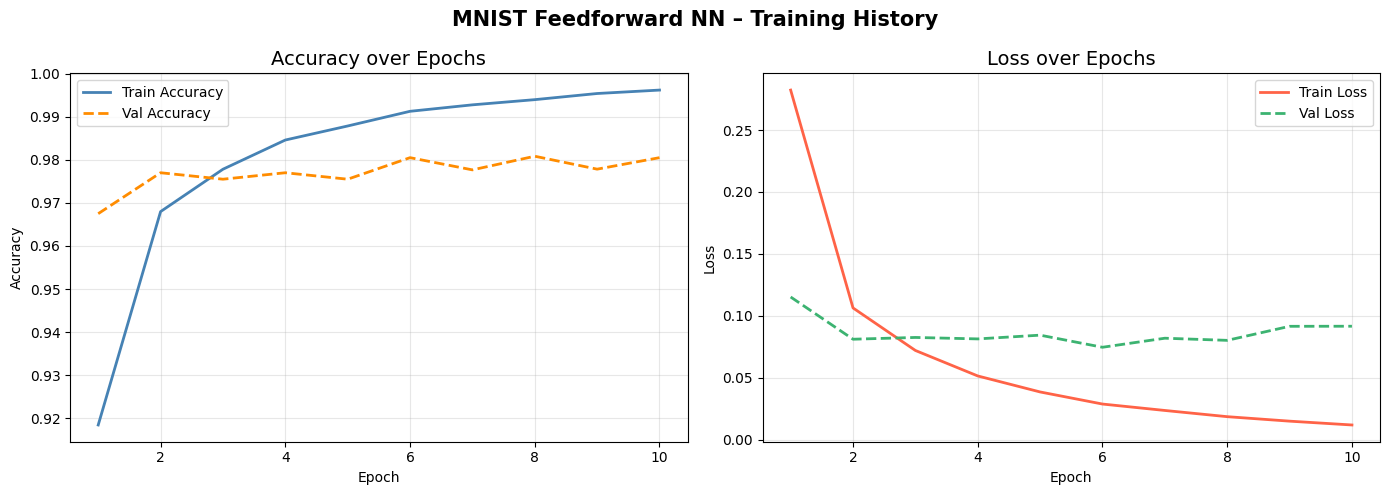

In [15]:
epochs_range = range(1, 11)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy ---
axes[0].plot(epochs_range, history.history['accuracy'],     label='Train Accuracy', color='steelblue',      linewidth=2)
axes[0].plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy',   color='darkorange',     linewidth=2, linestyle='--')
axes[0].set_title('Accuracy over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# --- Loss ---
axes[1].plot(epochs_range, history.history['loss'],     label='Train Loss', color='tomato',         linewidth=2)
axes[1].plot(epochs_range, history.history['val_loss'], label='Val Loss',   color='mediumseagreen', linewidth=2, linestyle='--')
axes[1].set_title('Loss over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('MNIST Feedforward NN – Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Evaluate Test Accuracy

In [16]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_ohe, verbose=0)

print("=" * 40)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy * 100:.2f}%")
print("=" * 40)

  Test Loss     : 0.0859
  Test Accuracy : 97.67%


## Step 8: Display Predictions for 5 Test Images

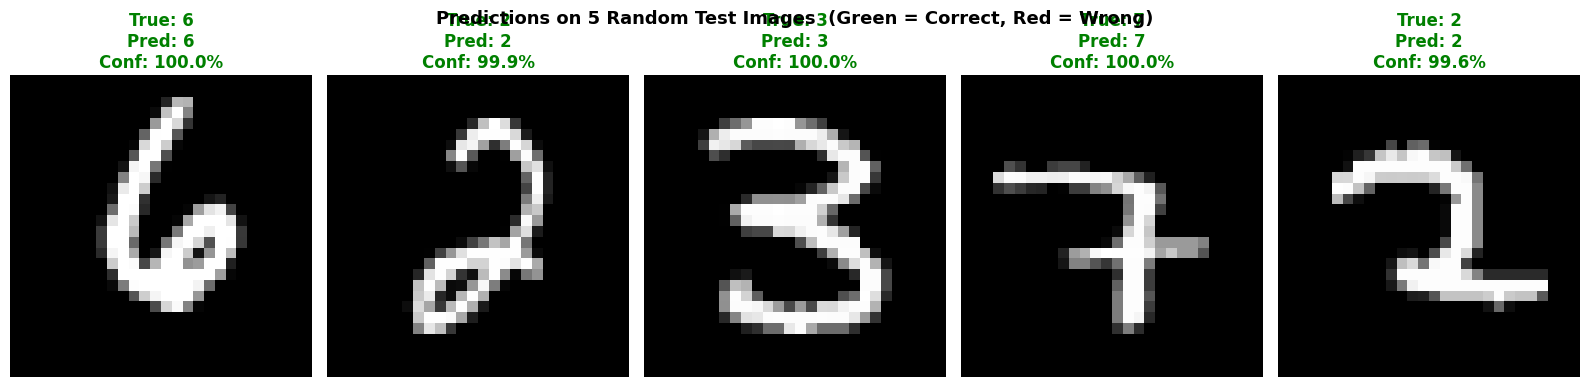


Detailed results:
  Image 1: True=6  Predicted=6  Confidence=100.00%  [CORRECT]
  Image 2: True=2  Predicted=2  Confidence=99.93%  [CORRECT]
  Image 3: True=3  Predicted=3  Confidence=100.00%  [CORRECT]
  Image 4: True=7  Predicted=7  Confidence=100.00%  [CORRECT]
  Image 5: True=2  Predicted=2  Confidence=99.61%  [CORRECT]


In [17]:
# Pick 5 random test images
np.random.seed(42)
indices = np.random.choice(len(X_test), 5, replace=False)

# Get model predictions (probabilities → class index)
predictions = model.predict(X_test[indices], verbose=0)
pred_labels = np.argmax(predictions, axis=1)
true_labels = y_test[indices]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for i, (ax, idx) in enumerate(zip(axes, indices)):
    img = X_test[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    color = 'green' if pred_labels[i] == true_labels[i] else 'red'
    ax.set_title(
        f"True: {true_labels[i]}\nPred: {pred_labels[i]}\nConf: {predictions[i][pred_labels[i]]*100:.1f}%",
        fontsize=12, color=color, fontweight='bold'
    )
    ax.axis('off')

plt.suptitle('Predictions on 5 Random Test Images  (Green = Correct, Red = Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDetailed results:")
for i in range(5):
    status = 'CORRECT' if pred_labels[i] == true_labels[i] else 'WRONG'
    print(f"  Image {i+1}: True={true_labels[i]}  Predicted={pred_labels[i]}  "
          f"Confidence={predictions[i][pred_labels[i]]*100:.2f}%  [{status}]")